# Gaussian-corruption CPU-grouper timing

This notebook strictly validates the CPU-grouper benchmark bundle before plotting it. Set `PIRATE_GAUSSIAN_CPU_GROUPER_RESULTS` to select a non-default CPU result directory. An existing production-GPU campaign is overlaid only when `PIRATE_GAUSSIAN_GPU_GROUPER_RESULTS` is explicitly set and every workload compatibility check succeeds.

The authoritative CPU-grouper wall time covers production normalization and validation, the minimal GPU-to-CPU transfer, host grouping, compact CPU-to-GPU result transfer, GPU result reconstruction, and the final CUDA-stream synchronization. The four figures below show raw trials, medians, interquartile ranges, and minimum–maximum spread.

In [1]:
%env PIRATE_GAUSSIAN_CPU_GROUPER_RESULTS=/home/mtrudu/src/pirate-updated/peakfinder_tests/results_gaussian_corruption_cpu_grouper_timing_current
%env PIRATE_GAUSSIAN_GPU_GROUPER_RESULTS=/home/mtrudu/src/pirate-updated/peakfinder_tests/results_gaussian_corruption_timing_new_gpu

env: PIRATE_GAUSSIAN_CPU_GROUPER_RESULTS=/home/mtrudu/src/pirate-updated/peakfinder_tests/results_gaussian_corruption_cpu_grouper_timing_current
env: PIRATE_GAUSSIAN_GPU_GROUPER_RESULTS=/home/mtrudu/src/pirate-updated/peakfinder_tests/results_gaussian_corruption_timing_new_gpu


In [2]:
import hashlib
import json
import math
import os
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import yaml

def find_repository_root():
    configured = os.environ.get('PIRATE_REPOSITORY_ROOT')
    starts = [Path(configured).expanduser()] if configured else []
    starts.append(Path.cwd())
    for start in starts:
        start = start.resolve()
        for candidate in (start, *start.parents):
            if (candidate / 'peakfinder_tests' / 'benchmark_gaussian_corruption_timing.py').is_file() and (candidate / 'pirate_frb').is_dir():
                return candidate
    raise FileNotFoundError(
        'cannot locate the PIRATE repository root; launch Jupyter from the repository or set PIRATE_REPOSITORY_ROOT'
    )

REPOSITORY_ROOT = find_repository_root()
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

from peakfinder_tests import benchmark_gaussian_corruption_cpu_grouper_timing as cpu_benchmark
from peakfinder_tests import benchmark_gaussian_corruption_timing as gpu_benchmark

EXPECTED_SHAPES = [
    (4096, 128), (1024, 64), (2048, 64), (1024, 64), (1024, 32),
    (2048, 32), (512, 32), (1024, 32), (1024, 16), (2048, 16),
]
EXPECTED_PIXELS_PER_BEAM = 983_040
CPU_SCHEMA_NAME = 'pirate-gaussian-corruption-cpu-grouper-timing'
GPU_SCHEMA_NAME = 'pirate-gaussian-corruption-timing'
SCHEMA_VERSION = 1
SUMMARY_STATISTICS = ('median', 'minimum', 'maximum', 'q25', 'q75', 'iqr')

configured = os.environ.get('PIRATE_GAUSSIAN_CPU_GROUPER_RESULTS')
if configured:
    RESULTS_DIR = Path(configured).expanduser()
else:
    candidates = [
        Path('peakfinder_tests/results_gaussian_corruption_cpu_grouper_timing'),
        Path('results_gaussian_corruption_cpu_grouper_timing'),
    ]
    RESULTS_DIR = next((path for path in candidates if path.is_dir()), candidates[0])

def load_exact_bundle(directory, benchmark_module):
    directory = Path(directory).expanduser().resolve()
    paths = {name: directory / name for name in ('trials.csv', 'summary.csv', 'metadata.yaml')}
    missing = [str(path) for path in paths.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError(f'missing benchmark result files: {missing}')
    trials = gpu_benchmark._read_csv_exact(paths['trials.csv'], benchmark_module.TRIAL_FIELDS)
    summary = gpu_benchmark._read_csv_exact(paths['summary.csv'], benchmark_module.SUMMARY_FIELDS)
    if not trials or not summary:
        raise ValueError(f'{directory}: trials.csv and summary.csv must be non-empty')
    with paths['metadata.yaml'].open(encoding='utf-8') as stream:
        metadata = yaml.safe_load(stream) or {}
    if not isinstance(metadata, dict):
        raise ValueError(f'{paths["metadata.yaml"]}: expected a YAML mapping')
    return directory, paths, trials, summary, metadata

def as_int(value, context):
    try:
        return int(value)
    except (TypeError, ValueError) as exc:
        raise ValueError(f'{context}: expected an integer, got {value!r}') from exc

def as_float(value, context, *, allow_missing=False):
    if allow_missing and (value is None or str(value).strip().lower() in {'', 'nan', 'none'}):
        return None
    try:
        result = float(value)
    except (TypeError, ValueError) as exc:
        raise ValueError(f'{context}: expected a number, got {value!r}') from exc
    if not np.isfinite(result):
        raise ValueError(f'{context}: expected a finite number, got {value!r}')
    return result

def close(observed, expected, context, *, rtol=1e-9, atol=1e-9):
    if not np.isclose(float(observed), float(expected), rtol=rtol, atol=atol):
        raise ValueError(f'{context}: observed {observed!r}, expected {expected!r}')

def validate_signature(metadata, schema_name):
    required = {
        'schema_name', 'schema_version', 'campaign_id', 'campaign_signature',
        'campaign_signature_payload', 'campaign', 'plan', 'corruption_model',
        'peakfinder', 'streaming_state', 'decoder_timing', 'environment',
        'csv_schemas', 'campaign_completeness',
    }
    if not required <= set(metadata):
        raise ValueError(f'metadata.yaml: missing sections {sorted(required - set(metadata))}')
    if metadata['schema_name'] != schema_name or as_int(metadata['schema_version'], 'metadata schema') != SCHEMA_VERSION:
        raise ValueError('metadata.yaml: unsupported schema')
    payload = metadata['campaign_signature_payload']
    if not isinstance(payload, dict):
        raise ValueError('metadata.yaml: campaign_signature_payload must be a mapping')
    computed = gpu_benchmark.campaign_signature(payload)
    if computed != metadata['campaign_signature']:
        raise ValueError('metadata.yaml: campaign signature does not match its payload')
    if metadata['campaign_id'] != computed[:16]:
        raise ValueError('metadata.yaml: campaign_id is not the signature prefix')

def validate_summary_rows(observed, expected, fields, context):
    if len(observed) != len(expected):
        raise ValueError(f'{context}: summary row count is inconsistent')
    for row_index, (actual, wanted) in enumerate(zip(observed, expected), start=2):
        for field in fields:
            left, right = actual[field], wanted[field]
            if field == 'campaign_id':
                if str(left) != str(right):
                    raise ValueError(f'{context}:{row_index}:{field} mismatch')
            elif right == '':
                if str(left).strip():
                    raise ValueError(f'{context}:{row_index}:{field} should be empty')
            else:
                close(left, right, f'{context}:{row_index}:{field}', rtol=1e-8, atol=1e-10)

cpu_directory, cpu_paths, trial_rows, summary_rows, metadata = load_exact_bundle(
    RESULTS_DIR, cpu_benchmark
)

In [3]:
validate_signature(metadata, CPU_SCHEMA_NAME)
for section in ('cpu_grouper', 'cpu_grouper_timing', 'production_reference_verification'):
    if section not in metadata:
        raise ValueError(f'metadata.yaml: missing CPU section {section!r}')
if metadata['csv_schemas'].get('trials.csv') != list(cpu_benchmark.TRIAL_FIELDS):
    raise ValueError('metadata.yaml: trials.csv schema disagrees with the benchmark schema')
if metadata['csv_schemas'].get('summary.csv') != list(cpu_benchmark.SUMMARY_FIELDS):
    raise ValueError('metadata.yaml: summary.csv schema disagrees with the benchmark schema')
if metadata['csv_schemas'].get('summary_metrics') != list(cpu_benchmark.SUMMARY_METRICS):
    raise ValueError('metadata.yaml: summary metric list is inconsistent')
if metadata['csv_schemas'].get('summary_statistics') != list(SUMMARY_STATISTICS):
    raise ValueError('metadata.yaml: summary statistic list is inconsistent')

plan = metadata['plan']
shapes = [tuple(map(int, shape)) for shape in plan['tree_shapes_ndm_ntime']]
if shapes != EXPECTED_SHAPES:
    raise ValueError(f'metadata.yaml: unexpected plan-derived shapes {shapes}')
pixels_per_beam = as_int(plan['pixels_per_beam'], 'metadata pixels_per_beam')
if pixels_per_beam != EXPECTED_PIXELS_PER_BEAM:
    raise ValueError('metadata.yaml: pixels_per_beam is not 983,040')
chunk_duration_ms = as_float(plan['chunk_duration_ms'], 'metadata chunk duration')
config_document = plan['config_document']
expected_chunk_duration_ms = (
    as_float(config_document['time_sample_ms'], 'config time sample')
    * as_int(config_document['time_samples_per_chunk'], 'config time samples per chunk')
)
close(chunk_duration_ms, expected_chunk_duration_ms, 'metadata chunk duration')
if metadata['corruption_model'].get('name') != 'gaussian_mixture':
    raise ValueError('metadata.yaml: corruption model is not gaussian_mixture')
if as_int(metadata['cpu_grouper'].get('host_bytes_per_candidate'), 'host bytes per candidate') != 72:
    raise ValueError('metadata.yaml: unexpected GPU-to-CPU byte policy')
required_diagnostics = {
    'candidate_normalization_ms', 'gpu_to_cpu_transfer_ms', 'cpu_grouping_ms',
    'cpu_to_gpu_result_ms', 'cpu_grouping_diagnostic_stage_sum_ms',
}
if not required_diagnostics <= set(metadata['cpu_grouper_timing'].get('diagnostics', ())):
    raise ValueError('metadata.yaml: CPU timing diagnostics are incomplete')
if metadata['cpu_grouper_timing'].get('authoritative_metric') != 'cpu_grouper_wall_ms':
    raise ValueError('metadata.yaml: CPU authoritative timing metric is inconsistent')

campaign = metadata['campaign']
total_beams = as_int(campaign['total_beams'], 'metadata total_beams')
beam_batch_size = as_int(campaign['beam_batch_size'], 'metadata beam_batch_size')
trial_count = as_int(campaign['trials'], 'metadata trials')
target_grid = tuple(float(value) for value in campaign['percentage_grid'])
if min(total_beams, beam_batch_size, trial_count) < 1 or not target_grid:
    raise ValueError('metadata.yaml: invalid campaign dimensions')
if len(target_grid) != len(set(target_grid)) or any(value < 0 for value in target_grid):
    raise ValueError('metadata.yaml: invalid percentage grid')
if as_int(campaign['total_pixels_per_trial'], 'metadata total pixels') != total_beams * pixels_per_beam:
    raise ValueError('metadata.yaml: total_pixels_per_trial is inconsistent')
validation_args = SimpleNamespace(
    total_beams=total_beams, beam_batch_size=beam_batch_size,
    threshold=as_float(metadata['peakfinder']['threshold'], 'threshold'),
    method=metadata['peakfinder']['method'],
    dm_reach=as_int(metadata['peakfinder']['dm_reach'], 'dm_reach'),
    waist_bins=as_int(metadata['peakfinder']['waist_bins'], 'waist_bins'),
    base_seed=as_int(campaign['base_seed'], 'base_seed'),
    calibration_pixel_tolerance=as_int(
        metadata['corruption_model']['calibration']['pixel_tolerance_per_beam'],
        'calibration pixel tolerance',
    ),
    candidate_safety_limit=as_int(
        metadata['production_reference_verification']['candidate_limit'],
        'production-reference candidate safety limit',
    ),
    verify_production_reference=bool(
        metadata['production_reference_verification']['enabled']
    ),
    allow_unsafe_grouping=bool(
        metadata['production_reference_verification']['unsafe_override']
    ),
)
cpu_benchmark.gaussian.validate_trial_prefix(
    trial_rows, trial_count, target_grid, metadata['campaign_id']
)
cpu_benchmark.validate_resumed_trial_rows(
    trial_rows, validation_args, metadata['campaign_id'], chunk_duration_ms,
)

calibration_tolerance = as_int(
    metadata['corruption_model']['calibration']['pixel_tolerance_per_beam'],
    'calibration tolerance',
)
completed_rows = []
for line_number, row in enumerate(trial_rows, start=2):
    context = f'trials.csv:{line_number}'
    if row['status'] != 'completed':
        continue
    completed_rows.append(row)
    target = as_float(row['target_corruption_percent'], context + ':target')
    target_per_beam = gpu_benchmark.target_count_from_percentage(target, pixels_per_beam)
    calibrations = json.loads(row['per_beam_calibration_json'])
    if not isinstance(calibrations, list) or len(calibrations) != total_beams:
        raise ValueError(f'{context}: expected one calibration entry per beam')
    beam_ids, achieved_counts, count_errors = [], [], []
    for item in calibrations:
        beam_ids.append(as_int(item['beam_id'], context + ':beam_id'))
        target_count = as_int(item['target_count'], context + ':target_count')
        achieved_count = as_int(item['achieved_count'], context + ':achieved_count')
        count_error = as_int(item['pixel_count_error'], context + ':pixel_count_error')
        if target_count != target_per_beam or count_error != achieved_count - target_count:
            raise ValueError(f'{context}: per-beam calibration count is inconsistent')
        if abs(count_error) > calibration_tolerance:
            raise ValueError(f'{context}: per-beam calibration exceeds tolerance')
        achieved_counts.append(achieved_count)
        count_errors.append(count_error)
    if sorted(beam_ids) != list(range(total_beams)):
        raise ValueError(f'{context}: invalid or duplicate beam IDs')
    above = as_int(row['total_pixels_above_threshold'], context + ':pixels above threshold')
    candidates = as_int(row['total_peakfinder_candidates'], context + ':candidates')
    decoded = as_int(row['total_decoded_candidates'], context + ':decoded')
    events = as_int(row['total_grouped_events'], context + ':events')
    if sum(achieved_counts) != above or candidates != decoded or not 0 <= events <= decoded:
        raise ValueError(f'{context}: aggregate count conservation failed')
    expected_total = target_per_beam * total_beams
    if as_int(row['pixel_count_error'], context + ':aggregate error') != above - expected_total:
        raise ValueError(f'{context}: aggregate pixel error is inconsistent')
    if as_int(row['max_abs_beam_pixel_count_error'], context + ':maximum beam error') != max(map(abs, count_errors), default=0):
        raise ValueError(f'{context}: maximum per-beam error is inconsistent')
    close(row['achieved_corruption_percent'], 100.0 * above / (total_beams * pixels_per_beam), context + ':achieved percent', atol=5e-12)
    close(row['peakfinder_survival_fraction'], candidates / above if above else 0.0, context + ':survival fraction')
    if np.isclose(target, 0.0, rtol=0.0, atol=1e-12) and any((above, candidates, decoded, events)):
        raise ValueError(f'{context}: zero corruption produced candidates or events')

expected_keys = set(cpu_benchmark.gaussian.expected_trial_keys(trial_count, target_grid))
actual_keys = {
    (int(row['trial']), cpu_benchmark.gaussian.canonical_percentage(row['target_corruption_percent']))
    for row in trial_rows
}
if actual_keys != expected_keys:
    raise ValueError('trials.csv does not contain the exact campaign grid')
completeness = metadata['campaign_completeness']
expected_configurations = trial_count * len(target_grid)
if completeness.get('complete') is not True:
    raise ValueError('metadata.yaml: campaign is incomplete')
if as_int(completeness['expected_configurations'], 'expected configurations') != expected_configurations:
    raise ValueError('metadata.yaml: expected configuration count is inconsistent')
if as_int(completeness['recorded_configurations'], 'recorded configurations') != len(trial_rows):
    raise ValueError('metadata.yaml: recorded configuration count is inconsistent')
observed_status_counts = {}
for row in trial_rows:
    observed_status_counts[row['status']] = observed_status_counts.get(row['status'], 0) + 1
if completeness.get('status_counts') != observed_status_counts:
    raise ValueError('metadata.yaml: status counts disagree with trials.csv')
if completeness.get('missing_configurations') not in ([], ( )):
    raise ValueError('metadata.yaml: completed campaign reports missing configurations')
if not completed_rows:
    raise ValueError('trials.csv contains no completed CPU-grouping configurations')
expected_summary = cpu_benchmark.summarize_trials(trial_rows, target_grid, metadata['campaign_id'])
validate_summary_rows(summary_rows, expected_summary, cpu_benchmark.SUMMARY_FIELDS, 'summary.csv')

In [4]:
configured_gpu = os.environ.get('PIRATE_GAUSSIAN_GPU_GROUPER_RESULTS')
GPU_RESULTS_ENV = (
    Path(configured_gpu).expanduser()
    if configured_gpu
    else REPOSITORY_ROOT / 'peakfinder_tests/results_gaussian_corruption_timing'
)
gpu_overlay_rows = []
if GPU_RESULTS_ENV:
    gpu_directory, gpu_paths, gpu_rows, gpu_summary_rows, gpu_metadata = load_exact_bundle(
        GPU_RESULTS_ENV, gpu_benchmark
    )
    validate_signature(gpu_metadata, GPU_SCHEMA_NAME)
    if gpu_metadata['csv_schemas'].get('trials.csv') != list(gpu_benchmark.TRIAL_FIELDS):
        raise ValueError('GPU overlay metadata disagrees with trials.csv schema')
    if gpu_metadata['csv_schemas'].get('summary.csv') != list(gpu_benchmark.SUMMARY_FIELDS):
        raise ValueError('GPU overlay metadata disagrees with summary.csv schema')
    gpu_campaign = gpu_metadata['campaign']
    gpu_grid = tuple(float(value) for value in gpu_campaign['percentage_grid'])
    compatibility_pairs = (
        ('percentage grid', gpu_grid, target_grid),
        ('trial count', as_int(gpu_campaign['trials'], 'GPU trials'), trial_count),
        ('total beams', as_int(gpu_campaign['total_beams'], 'GPU total beams'), total_beams),
        ('beam batch size', as_int(gpu_campaign['beam_batch_size'], 'GPU batch size'), beam_batch_size),
        ('base seed', as_int(gpu_campaign['base_seed'], 'GPU base seed'), validation_args.base_seed),
        ('plan shapes', [tuple(map(int, shape)) for shape in gpu_metadata['plan']['tree_shapes_ndm_ntime']], shapes),
        ('pixels per beam', as_int(gpu_metadata['plan']['pixels_per_beam'], 'GPU pixels per beam'), pixels_per_beam),
        ('chunk duration', as_float(gpu_metadata['plan']['chunk_duration_ms'], 'GPU chunk duration'), chunk_duration_ms),
        ('config hash', gpu_metadata['plan']['config_sha256'], plan['config_sha256']),
        ('producer plan hash', gpu_metadata['plan']['producer_plan_sha256'], plan['producer_plan_sha256']),
        ('corruption model', gpu_metadata['corruption_model'], metadata['corruption_model']),
        ('argmax policy', gpu_metadata.get('argmax_tokens'), metadata.get('argmax_tokens')),
        ('peakfinder configuration', gpu_metadata['peakfinder'], metadata['peakfinder']),
        ('streaming policy', gpu_metadata['streaming_state'], metadata['streaming_state']),
    )
    for label, observed, expected in compatibility_pairs:
        if observed != expected:
            raise ValueError(f'GPU overlay is incompatible: {label} differs')
    gpu_grouping = gpu_metadata.get('grouper_timing', {})
    close(gpu_grouping.get('dm_tolerance_bins'), metadata['cpu_grouper']['dm_tolerance_bins'], 'GPU overlay DM tolerance')
    close(gpu_grouping.get('time_padding_bins'), metadata['cpu_grouper']['time_padding_bins'], 'GPU overlay time padding')
    cpu_sources = metadata['environment']['production_sources']
    gpu_sources = gpu_metadata['environment']['production_sources']
    for source_name in ('Peakfinders', 'GpuArgmaxDecoder', 'OfflineCandidateGrouper'):
        if cpu_sources[source_name]['sha256'] != gpu_sources[source_name]['sha256']:
            raise ValueError(f'GPU overlay is incompatible: {source_name} source hash differs')
    gpu_args = SimpleNamespace(
        total_beams=total_beams, beam_batch_size=beam_batch_size,
        threshold=validation_args.threshold, method=validation_args.method,
        dm_reach=validation_args.dm_reach, waist_bins=validation_args.waist_bins,
        base_seed=validation_args.base_seed,
        calibration_pixel_tolerance=validation_args.calibration_pixel_tolerance,
        candidate_safety_limit=as_int(gpu_metadata['safety_limit']['candidate_limit'], 'GPU safety limit'),
        allow_unsafe_grouping=bool(gpu_metadata['safety_limit']['unsafe_override']),
    )
    gpu_benchmark.validate_trial_prefix(gpu_rows, trial_count, target_grid, gpu_metadata['campaign_id'])
    gpu_benchmark.validate_resumed_trial_rows(
        gpu_rows, gpu_args, gpu_metadata['campaign_id'], chunk_duration_ms,
    )
    if gpu_metadata['campaign_completeness'].get('complete') is not True:
        raise ValueError('GPU overlay campaign is incomplete')
    expected_gpu_summary = gpu_benchmark.summarize_trials(gpu_rows, target_grid, gpu_metadata['campaign_id'])
    validate_summary_rows(gpu_summary_rows, expected_gpu_summary, gpu_benchmark.SUMMARY_FIELDS, 'GPU summary.csv')
    cpu_by_key = {
        (int(row['trial']), cpu_benchmark.gaussian.canonical_percentage(row['target_corruption_percent'])): row
        for row in trial_rows
    }
    gpu_by_key = {
        (int(row['trial']), gpu_benchmark.canonical_percentage(row['target_corruption_percent'])): row
        for row in gpu_rows
    }
    if set(cpu_by_key) != set(gpu_by_key):
        raise ValueError('GPU overlay has different trial/percentage keys')
    for key in sorted(cpu_by_key):
        cpu_row, gpu_row = cpu_by_key[key], gpu_by_key[key]
        gpu_safety_skip = (
            cpu_row['status'] == 'completed'
            and gpu_row['status'] == 'skipped_candidate_safety_limit'
        )
        if cpu_row['status'] != gpu_row['status'] and not gpu_safety_skip:
            raise ValueError(f'GPU overlay status differs at {key}')
        if cpu_row['status'] != 'completed':
            continue
        for field in (
            'seed', 'total_gaussians', 'total_pixels_above_threshold',
            'total_peakfinder_candidates', 'total_decoded_candidates',
        ):
            if as_int(cpu_row[field], f'CPU {key}:{field}') != as_int(gpu_row[field], f'GPU {key}:{field}'):
                raise ValueError(f'GPU overlay workload differs at {key}: {field}')
        close(cpu_row['achieved_corruption_percent'], gpu_row['achieved_corruption_percent'], f'GPU overlay achieved percentage at {key}', atol=5e-12)
        if json.loads(cpu_row['per_beam_calibration_json']) != json.loads(gpu_row['per_beam_calibration_json']):
            raise ValueError(f'GPU overlay calibration differs at {key}')
        if gpu_row['status'] == 'completed':
            gpu_overlay_rows.append(gpu_row)

In [5]:
targets = np.asarray(sorted(target_grid), dtype=float)

def finite_pairs(rows, xfield, yfield):
    pairs = []
    for row in rows:
        x = as_float(row.get(xfield), xfield, allow_missing=True)
        y = as_float(row.get(yfield), yfield, allow_missing=True)
        if x is not None and y is not None:
            pairs.append((x, y))
    if not pairs:
        raise ValueError(f'no finite pairs for {xfield} versus {yfield}')
    return np.asarray(pairs, dtype=float).T

def values_by_target(rows, field):
    result = []
    for target in targets:
        values = [
            as_float(row.get(field), field, allow_missing=True)
            for row in rows
            if np.isclose(float(row['target_corruption_percent']), target, rtol=0.0, atol=1e-12)
        ]
        values = np.asarray([value for value in values if value is not None], dtype=float)
        if values.size:
            result.append((
                target, np.min(values), np.quantile(values, 0.25),
                np.median(values), np.quantile(values, 0.75), np.max(values),
            ))
    return np.asarray(result, dtype=float).T

def relationship_by_target(rows, xfield, yfield):
    result = []
    for target in targets:
        selected = [
            row for row in rows
            if np.isclose(float(row['target_corruption_percent']), target, rtol=0.0, atol=1e-12)
        ]
        if not selected:
            continue
        x, y = finite_pairs(selected, xfield, yfield)
        result.append((
            np.min(x), np.quantile(x, 0.25), np.median(x), np.quantile(x, 0.75), np.max(x),
            np.min(y), np.quantile(y, 0.25), np.median(y), np.quantile(y, 0.75), np.max(y),
        ))
    return np.asarray(result, dtype=float).T

def draw_target_summary(ax, rows, field, *, color, label, linestyle='-'):
    x, minimum, q25, median, q75, maximum = values_by_target(rows, field)
    ax.fill_between(x, minimum, maximum, color=color, alpha=0.09, label=f'{label} min–max')
    ax.fill_between(x, q25, q75, color=color, alpha=0.20, label=f'{label} IQR')
    ax.plot(x, median, color=color, marker='o', linewidth=2, linestyle=linestyle, label=f'{label} median')

def draw_relationship_summary(ax, rows, xfield, yfield, *, color, label, linestyle='-'):
    xmin, xq25, xmed, xq75, xmax, ymin, yq25, ymed, yq75, ymax = relationship_by_target(rows, xfield, yfield)
    ax.errorbar(
        xmed, ymed, xerr=np.vstack((xmed - xmin, xmax - xmed)),
        yerr=np.vstack((ymed - ymin, ymax - ymed)), fmt='none',
        ecolor=color, alpha=0.22, capsize=3, label=f'{label} min–max',
    )
    ax.errorbar(
        xmed, ymed, xerr=np.vstack((xmed - xq25, xq75 - xmed)),
        yerr=np.vstack((ymed - yq25, yq75 - ymed)), fmt='none',
        ecolor=color, alpha=0.65, linewidth=2, capsize=3, label=f'{label} IQR',
    )
    ax.plot(xmed, ymed, color=color, marker='o', linewidth=2, linestyle=linestyle, label=f'{label} median')

def use_zero_safe_log_x(ax, values):
    positive = np.asarray(values, dtype=float)
    positive = positive[positive > 0]
    if positive.size:
        ax.set_xscale('symlog', linthresh=max(float(np.min(positive)) / 2.0, 1e-12))

plt.rcParams.update({'figure.figsize': (9.5, 6.0), 'axes.grid': True, 'grid.alpha': 0.25})

Corruption percentage controls above-threshold pixel occupancy, not the number of peaks. The same Gaussian morphologies are amplitude-scaled across percentages; broadening and overlap can therefore reduce the number of surviving candidates at high corruption. A downward timing point is meaningful when the candidate count also falls and must not be interpreted as faster grouping at a fixed load.

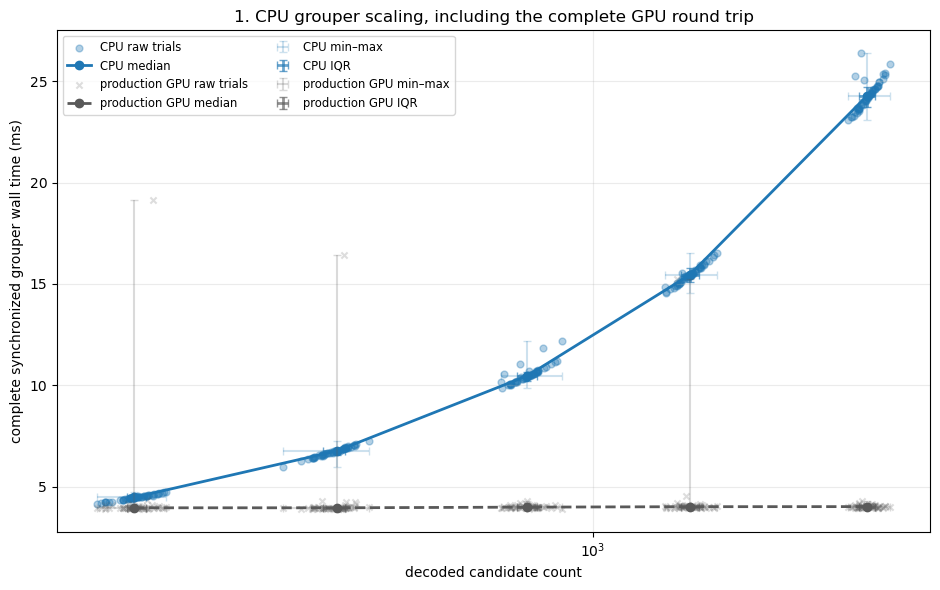

In [6]:
# 1. Complete synchronized CPU-grouper wall time versus candidate count
fig, ax = plt.subplots()
x, y = finite_pairs(completed_rows, 'total_decoded_candidates', 'cpu_grouper_wall_ms')
ax.scatter(x, y, s=24, alpha=0.34, color='tab:blue', label='CPU raw trials')
draw_relationship_summary(
    ax, completed_rows, 'total_decoded_candidates', 'cpu_grouper_wall_ms',
    color='tab:blue', label='CPU',
)
if gpu_overlay_rows:
    gx, gy = finite_pairs(gpu_overlay_rows, 'total_decoded_candidates', 'grouper_wall_ms')
    ax.scatter(gx, gy, s=20, alpha=0.20, color='0.35', marker='x', label='production GPU raw trials')
    draw_relationship_summary(
        ax, gpu_overlay_rows, 'total_decoded_candidates', 'grouper_wall_ms',
        color='0.35', label='production GPU', linestyle='--',
    )
use_zero_safe_log_x(ax, x)
ax.set_xlabel('decoded candidate count')
ax.set_ylabel('complete synchronized grouper wall time (ms)')
ax.set_title('1. CPU grouper scaling, including the complete GPU round trip')
ax.legend(fontsize='small', ncol=2)
fig.tight_layout()
plt.show()

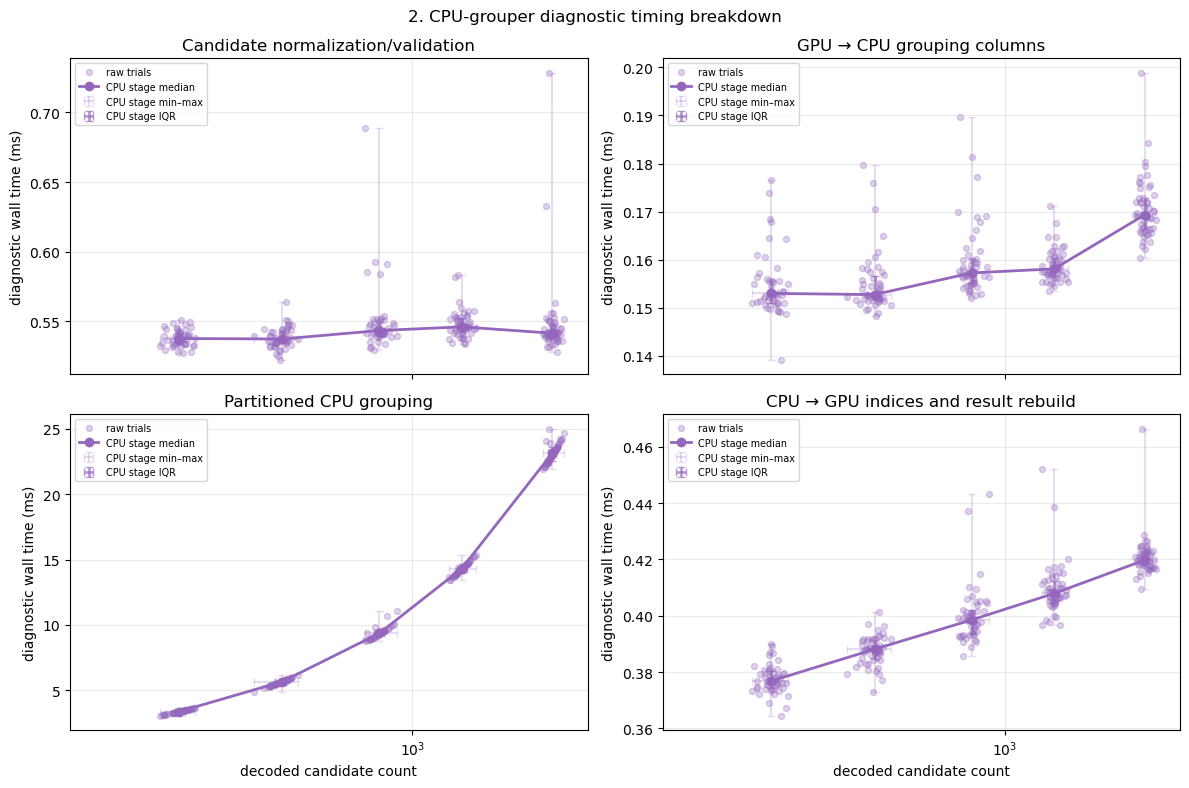

In [7]:
# 2. Diagnostic CPU-grouper stage breakdown versus candidate count
breakdown = (
    ('candidate_normalization_ms', 'Candidate normalization/validation'),
    ('gpu_to_cpu_transfer_ms', 'GPU → CPU grouping columns'),
    ('cpu_grouping_ms', 'Partitioned CPU grouping'),
    ('cpu_to_gpu_result_ms', 'CPU → GPU indices and result rebuild'),
)
fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.0), sharex=True)
for ax, (field, title) in zip(axes.flat, breakdown):
    x, y = finite_pairs(completed_rows, 'total_decoded_candidates', field)
    ax.scatter(x, y, s=19, alpha=0.30, color='tab:purple', label='raw trials')
    draw_relationship_summary(
        ax, completed_rows, 'total_decoded_candidates', field,
        color='tab:purple', label='CPU stage',
    )
    use_zero_safe_log_x(ax, x)
    ax.set_title(title)
    ax.set_ylabel('diagnostic wall time (ms)')
    ax.legend(fontsize='x-small')
for ax in axes[-1, :]:
    ax.set_xlabel('decoded candidate count')
fig.suptitle('2. CPU-grouper diagnostic timing breakdown')
fig.tight_layout()
plt.show()

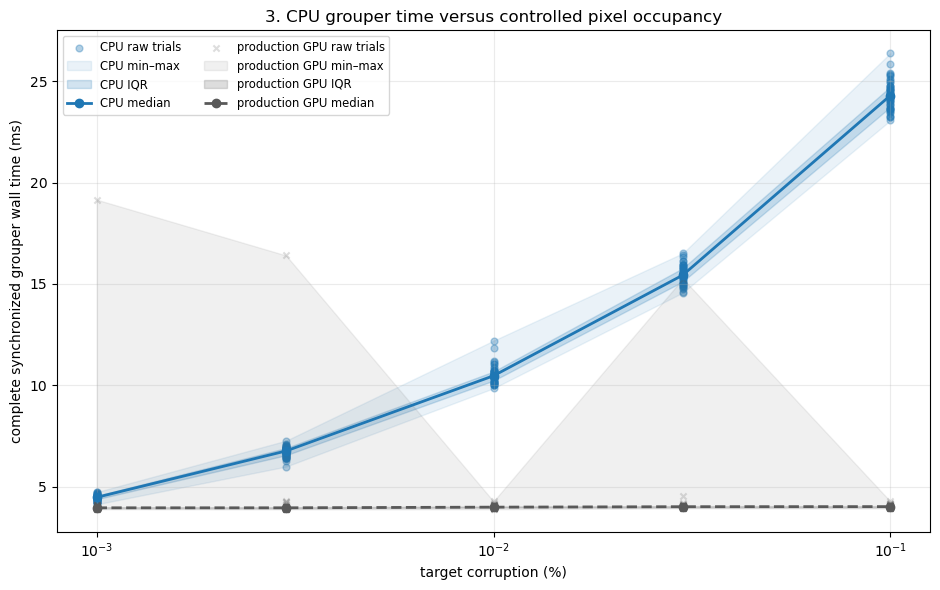

In [8]:
# 3. Complete CPU-grouper wall time versus corruption percentage
fig, ax = plt.subplots()
x, y = finite_pairs(completed_rows, 'target_corruption_percent', 'cpu_grouper_wall_ms')
ax.scatter(x, y, s=24, alpha=0.34, color='tab:blue', label='CPU raw trials')
draw_target_summary(ax, completed_rows, 'cpu_grouper_wall_ms', color='tab:blue', label='CPU')
if gpu_overlay_rows:
    gx, gy = finite_pairs(gpu_overlay_rows, 'target_corruption_percent', 'grouper_wall_ms')
    ax.scatter(gx, gy, s=20, alpha=0.20, color='0.35', marker='x', label='production GPU raw trials')
    draw_target_summary(
        ax, gpu_overlay_rows, 'grouper_wall_ms', color='0.35',
        label='production GPU', linestyle='--',
    )
use_zero_safe_log_x(ax, x)
ax.set_xlabel('target corruption (%)')
ax.set_ylabel('complete synchronized grouper wall time (ms)')
ax.set_title('3. CPU grouper time versus controlled pixel occupancy')
ax.legend(fontsize='small', ncol=2)
fig.tight_layout()
plt.show()

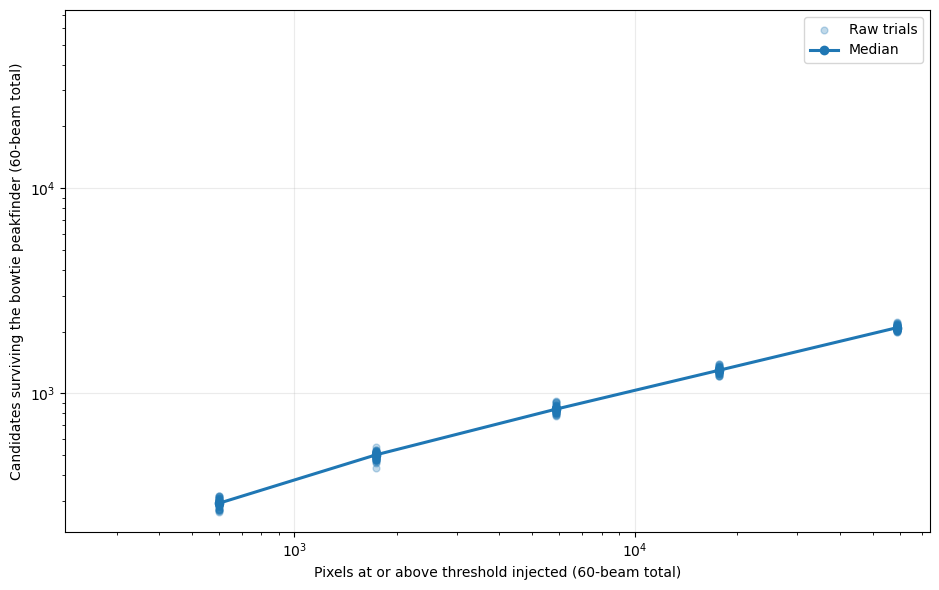

In [9]:
# 4. Bowtie peakfinder suppression across all 60 beams
raw_above, raw_survived = finite_pairs(
    completed_rows, 'total_pixels_above_threshold',
    'total_peakfinder_candidates',
)
positive = (raw_above > 0) & (raw_survived > 0)
if not np.any(positive):
    raise ValueError('no positive injected/surviving count pairs to plot')

median_points = []
for target in targets:
    selected = [
        row for row in completed_rows
        if np.isclose(
            float(row['target_corruption_percent']), target,
            rtol=0, atol=1e-12,
        )
    ]
    pairs = [
        (float(row['total_pixels_above_threshold']),
         float(row['total_peakfinder_candidates']))
        for row in selected
        if float(row['total_pixels_above_threshold']) > 0
        and float(row['total_peakfinder_candidates']) > 0
    ]
    if pairs:
        injected, survived = np.asarray(pairs, dtype=float).T
        median_points.append((np.median(injected), np.median(survived)))

median_injected, median_survived = np.asarray(
    sorted(median_points), dtype=float,
).T
plot_min = min(raw_above[positive].min(), raw_survived[positive].min())
plot_max = max(raw_above[positive].max(), raw_survived[positive].max())

fig, ax = plt.subplots(figsize=(9.5, 6.0))
ax.scatter(
    raw_above[positive], raw_survived[positive],
    s=24, alpha=0.28, color='tab:blue', label='Raw trials',
)
ax.plot(
    median_injected, median_survived, color='tab:blue', marker='o',
    linewidth=2.2, markersize=6, label='Median',
)
#ax.plot(
#    [plot_min, plot_max], [plot_min, plot_max],
#    color='0.45', linestyle='--', linewidth=1.5,
#    label='No suppression ($y=x$)',
#)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.8 * plot_min, 1.25 * plot_max)
ax.set_ylim(0.8 * plot_min, 1.25 * plot_max)
ax.set_xlabel('Pixels at or above threshold injected (60-beam total)')
ax.set_ylabel('Candidates surviving the bowtie peakfinder (60-beam total)')
ax.legend(loc='best')
fig.tight_layout()
plt.show()

/tmp/ipykernel_544619/275229218.py:90: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  time_ax.set_ylim(bottom=0.0)


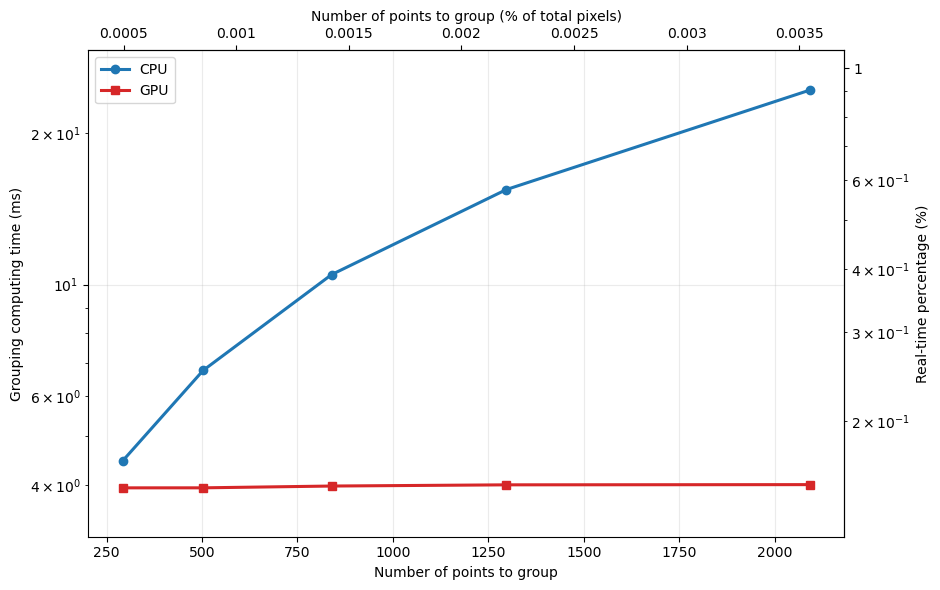

In [10]:
# 9. Median CPU and GPU grouper-only wall time versus points to group
from matplotlib.ticker import FuncFormatter

if not gpu_overlay_rows:
    raise ValueError('the compatible GPU campaign contains no completed grouping rows')

def median_grouper_curve(rows, time_field):
    points = []
    for target in targets:
        selected = [
            row for row in rows
            if np.isclose(
                float(row['target_corruption_percent']), target,
                rtol=0, atol=1e-12,
            )
        ]
        pairs = []
        for row in selected:
            candidate_count = as_float(
                row['total_decoded_candidates'], 'total_decoded_candidates',
                allow_missing=True,
            )
            grouper_ms = as_float(
                row[time_field], time_field, allow_missing=True,
            )
            if candidate_count is not None and grouper_ms is not None:
                pairs.append((candidate_count, grouper_ms))
        if pairs:
            candidates, times = np.asarray(pairs, dtype=float).T
            points.append((np.median(candidates), np.median(times)))
    if not points:
        raise ValueError(f'no finite median curve for {time_field}')
    return np.asarray(sorted(points), dtype=float).T

cpu_points, cpu_grouping_ms = median_grouper_curve(
    completed_rows, 'cpu_grouper_wall_ms',
)
gpu_points, gpu_grouping_ms = median_grouper_curve(
    gpu_overlay_rows, 'grouper_wall_ms',
)
if not np.allclose(cpu_points, gpu_points, rtol=0, atol=1e-12):
    raise ValueError('paired CPU and GPU median candidate counts differ')

total_pixels = float(total_beams * pixels_per_beam)

fig, time_ax = plt.subplots(figsize=(9.5, 6.0))
time_ax.plot(
    cpu_points, cpu_grouping_ms, color='tab:blue', marker='o',
    linewidth=2.2, markersize=6, label='CPU',
)
time_ax.plot(
    gpu_points, gpu_grouping_ms, color='tab:red', marker='s',
    linewidth=2.2, markersize=6, label='GPU',
)

points_percent_ax = time_ax.secondary_xaxis(
    'top',
    functions=(
        lambda points: 100.0 * np.asarray(points) / total_pixels,
        lambda percent: np.asarray(percent) * total_pixels / 100.0,
    ),
)

time_ax.set_yscale("log")

time_ax.set_ylim(
    0.8 * min(cpu_grouping_ms.min(), gpu_grouping_ms.min()),
    1.2 * max(cpu_grouping_ms.max(), gpu_grouping_ms.max()),
)

realtime_ax = time_ax.secondary_yaxis(
    'right',
    functions=(
        lambda milliseconds: 100.0 * np.asarray(milliseconds) / chunk_duration_ms,
        lambda percent: np.asarray(percent) * chunk_duration_ms / 100.0,
    ),
)

time_ax.set_xlabel('Number of points to group')
points_percent_ax.set_xlabel('Number of points to group (% of total pixels)')
time_ax.set_ylabel('Grouping computing time (ms)')
realtime_ax.set_ylabel('Real-time percentage (%)')
points_percent_ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f'{value:.3g}')
)
realtime_ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f'{value:g}')
)
time_ax.ticklabel_format(style='plain', axis='x')
time_ax.set_ylim(bottom=0.0)
time_ax.margins(x=0.05)
time_ax.legend(loc='best')
fig.tight_layout()
plt.show()